# Notebook for SmartSolo example file (SEG-D rev2.1)

In [1]:
from SEGD_reader import SEG_D_to_stream

In [2]:
# Simplest way to get data (to obspy stream):
st = SEG_D_to_stream('./data/453005563.0001.2024.06.30.19.35.34.000.Z.segd')
st.sort()

1 Trace(s) in Stream:
AA.line_1_point_1..DHZ | 2024-06-30T19:35:34.000000Z - 2024-07-01T00:05:34.032000Z | 250.0 Hz, 4050009 samples

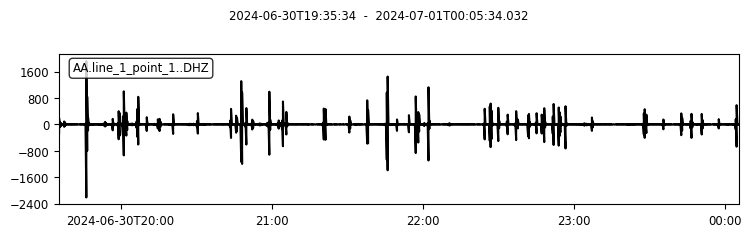

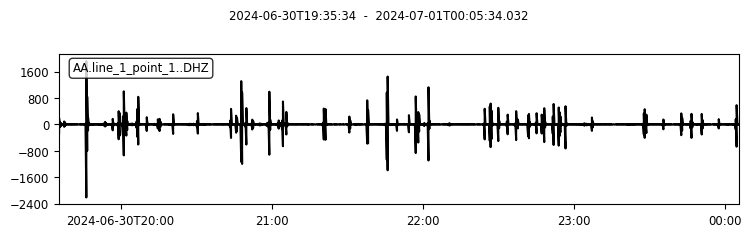

In [3]:
st.plot()

In [4]:
st[0].stats

         network: AA
         station: line_1_point_1
        location: 
         channel: DHZ
       starttime: 2024-06-30T19:35:34.000000Z
         endtime: 2024-07-01T00:05:34.032000Z
   sampling_rate: 250.0
           delta: 0.004
            npts: 4050009
           calib: 1.0
            segd: AttribDict({'serialNumber': 'line_1_point_1', 'fileNumber': '0000', 'SEGDVersion': '2.1', 'year': '24', 'jday': '182', 'hour': '19', 'minute': '35', 'second': '34', 'duration_microsec': 1800000000.0, 'dominant_sampling_interval_microsec': 4000.0, 'record_timezero_utc': UTCDateTime(2024, 6, 30, 19, 35, 34), 'trace_format_code': '8058', 'scanTypeNumber': '01', 'channelSetNumber': '01', 'channelSetStartTime': 0, 'channelSetEndTime': 48032, 'descaleMultiplierExtendedResolution': 0, 'descaleMultiplier': -104, 'numberOfChannelsThisSet': '0009', 'channelType': '1', 'samplesPerChannel': '0', 'channelGain': '3', 'aliasFilterFrequency': '0103', 'aliasFilterSlope': '288', 'lowCutFilter': '0000', 'lowC

In [5]:
# If you wish to take a look at the file header information etc, you can play around with the underlying SEG_D_Reader class:

from SEGD_reader import SEG_D_Reader # Import SEG-D reader class

reader = SEG_D_Reader('./data/453005563.0001.2024.06.30.19.35.34.000.Z.segd') # Initialise reader
reader.open_file() # Open SEG-D file (returns 'True' if successful)

True

In [6]:
# Get SEG-D version number for file:
version_number = reader.get_segd_version()
version_number

'SEG-D version number: 2.1'

In [7]:
# Get general file headers only:
reader.get_general_headers_only()

{'general_header1': {'fileNumber': '0000',
  'formatCode': '8058',
  'generalConstants': '000000000005',
  'year': '24',
  'generalHeaderBlocks': '2',
  'day': '182',
  'hour': '19',
  'minute': '35',
  'second': '34',
  'manufacturersCode': '61',
  'manunfacturersSerialNumber': '0000',
  'unusedFirst': '000000',
  'baseScanInterval': 4.0,
  'polarity': '0',
  'unusedSecond': '200',
  'recordType': '8',
  'recordLength': 'fff',
  'scanTypesPerRecord': '01',
  'channelSetsPerScanType': '16',
  'skewBlocks': '00',
  'extendedHeaderBlocks': '32',
  'externalHeaderBlocks': '32'},
 'general_header2': {'expandedFileNumber': 0,
  'extendedChannelSetsPerScanType': 0,
  'extendedHeaderBlocks': 0,
  'externalHeaderBlocks': 0,
  'majorSEGDrevisionNumber': 2,
  'minorSEGDrevisionNumber': 1,
  'generalTrailerBlocks': 0,
  'extendedRecordLength': 1800000,
  'sequenceNumber': 0},
 'general_header3': {'expandedFileNumber': 0,
  'sourceLineNumber': 0,
  'sourceLineNumberFraction': 0.0,
  'sourcePointNu

In [8]:
# And if you want to get the key header and data info used for obspy streams:
key_data = reader.get_data_plus_key_headers()

In [9]:
list(key_data.keys())

['file_header', '01_01']

In [10]:
key_data['file_header']

{'fileNumber': '0000',
 'SEGDVersion': '2.1',
 'year': '24',
 'jday': '182',
 'hour': '19',
 'minute': '35',
 'second': '34',
 'duration_microsec': 1800000000.0,
 'dominant_sampling_interval_microsec': 4000.0,
 'record_timezero_utc': 2024-06-30T19:35:34.000000Z,
 'trace_format_code': '8058'}

In [11]:
key_data['01_01']

{'description': {'scanTypeNumber': '01',
  'channelSetNumber': '01',
  'channelSetStartTime': 0,
  'channelSetEndTime': 48032,
  'descaleMultiplierExtendedResolution': 0,
  'descaleMultiplier': -104,
  'numberOfChannelsThisSet': '0009',
  'channelType': '1',
  'samplesPerChannel': '0',
  'channelGain': '3',
  'aliasFilterFrequency': '0103',
  'aliasFilterSlope': '288',
  'lowCutFilter': '0000',
  'lowCutFilterSlope': '012',
  'firstNotchFilter': '0000',
  'secondNotchFilter': '0000',
  'thirdNotchFilter': '0000',
  'extendedChannelSetNumber': 0,
  'extendedHeaderFlag': 0,
  'traceHeaderExtension': 7,
  'verticalStack': 1,
  'streamerNumber': 0,
  'arrayForming': 1},
 'traceData': {'line_1': {'point_1': {'0001': {'trace_header': {'sensorType_code': 2,
      'numSamplesPerTrace': 450001},
     'trace_data': (0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
 

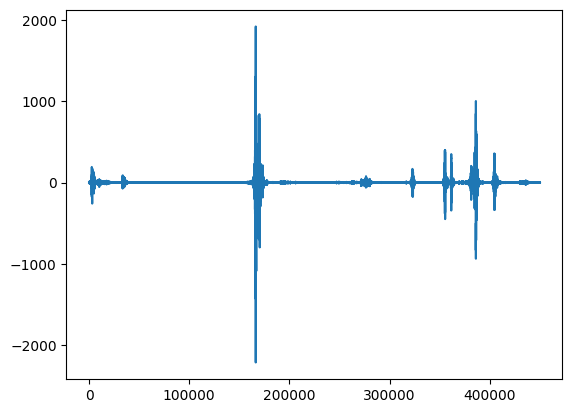

In [12]:
import matplotlib.pyplot as plt

plt.plot(key_data['01_01']['traceData']['line_1']['point_1']['0001']['trace_data']) # Plot trace 1
plt.show()

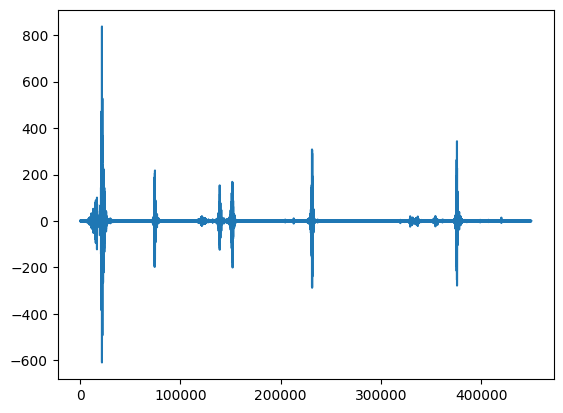

In [13]:
plt.plot(key_data['01_01']['traceData']['line_1']['point_1']['0002']['trace_data']) # Plot trace 2
plt.show()

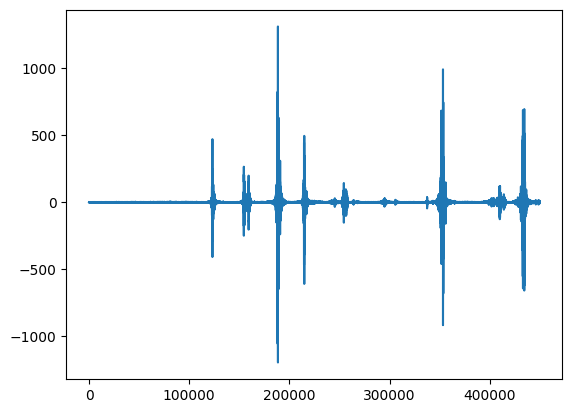

In [14]:
plt.plot(key_data['01_01']['traceData']['line_1']['point_1']['0003']['trace_data']) # Plot trace 3, etc...
plt.show()

In [15]:
# The above traces are concatenated by SEG_D_to_stream into one if same sensor (same line number and point number in header info)